In [1]:
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
from uphate.uphate import (
    get_phate_embedding,
    get_phate_embedding_jit,
    get_phate_embedding_bootstrap,
)
from uphate.utils import align_embeddings
from phate.tree import gen_dla

In [2]:
X, labels = gen_dla(n_branch=10)

In [21]:
embeddings = get_phate_embedding_bootstrap(
    jnp.array(X),
    jax.random.key(20),
    n_samples=10,
    t=20,
)

100%|██████████| 10/10 [00:29<00:00,  2.95s/it]


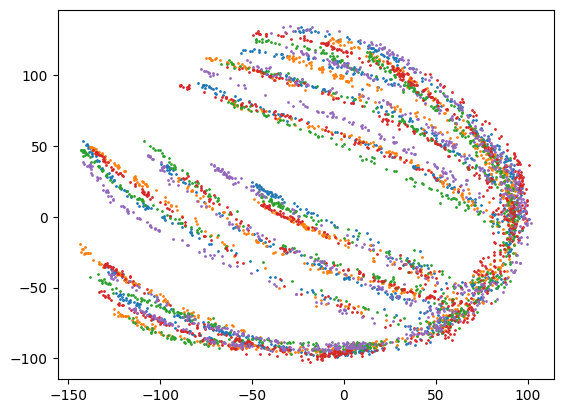

In [22]:
aligned_embeddings = jnp.array(
    list(map(lambda e: align_embeddings(embeddings[0], e), embeddings))
)
for emb in aligned_embeddings[:5]:
    plt.scatter(*emb.T, s=1)

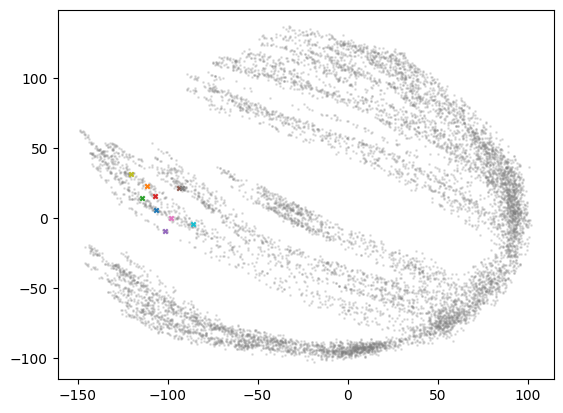

In [25]:
from random import randint


index = randint(0, len(X))

for emb in aligned_embeddings:
    plt.scatter(*emb.T, c="gray", alpha=0.2, s=1)

for emb in aligned_embeddings:
    plt.scatter(*emb[index].T, s=10, marker="x")

In [2]:
# Using smaller dataset for now since full jac is expensive
X, labels = gen_dla(n_branch=5, n_dim=10, branch_length=50)

In [ ]:
X_uphate = get_phate_embedding_jit(
    X,
    jax.random.key(20),
    t=5,
).block_until_ready()

In [ ]:
X_uphate_jac = jax.jit(
    jax.jacobian(get_phate_embedding),
    static_argnames=[
        "t",
        "n_components",
        "knn",
        "decay",
        "n_landmark",
        "gamma",
        "threshold",
    ],
)(
    X,
    jax.random.key(20),
    t=5,
)
X_uphate_jac.block_until_ready()

(-7.6197991371154785, 10.624106407165527)

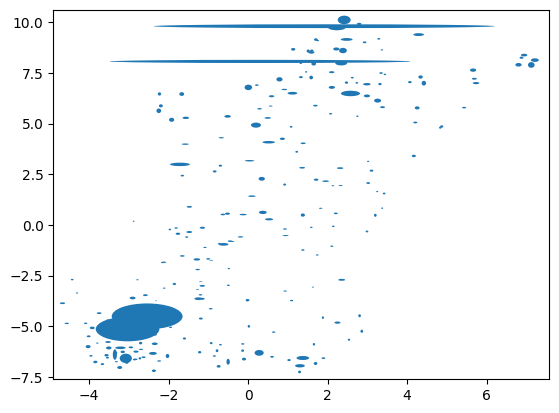

In [8]:
from matplotlib.collections import EllipseCollection

grad_magnitudes = jnp.linalg.norm(X_uphate_jac, axis=(2, 3)) * 0.01

fig, ax = plt.subplots()
ec = EllipseCollection(
    widths=grad_magnitudes[:, 0],
    heights=grad_magnitudes[:, 1],
    angles=jnp.zeros(grad_magnitudes.shape[0]),
    offsets=X_uphate,
    units="xy",
    transOffset=ax.transData
)

ax.add_collection(ec)
ax.set_xlim(X_uphate[:, 0].min() * 1.05, X_uphate[:, 0].max() * 1.05)
ax.set_ylim(X_uphate[:, 1].min() * 1.05, X_uphate[:, 1].max() * 1.05)